# Scaled Dot-Product Self-Attention Prototype

[Contents]  
학습되지 않은 단일 헤드 Self-Attention의 계산 구조를 직접 구현

- 입력 문장: I study AI hard
- 코퍼스: 사용자가 업로드한 mini_corpus.txt
- Tokenizer: 정규식 기반 소문자 토크나이저
- Vocabulary: 정렬된 단어 목록으로 고정
- 출력: Q, K, V, Attention Scores, Attention Weights, Context Vectors

[Note]  
- Embedding과 Q/K/V 선형변환은 랜덤 초기화 상태
- 따라서 Attention Weight의 크기를 언어적 중요도나 실제 의미 관계로 해석하면 안 됨  
- 이 실습의 목적은 Self-Attention의 계산 메커니즘과 텐서 구조를 코드로 확인하는 것


## 1. 라이브러리 Import

- Colab 기본 환경에 포함된 PyTorch를 사용


In [1]:
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn

# 재현 가능한 예시 출력을 위한 시드 고정
torch.manual_seed(42)

print("PyTorch version:", torch.__version__)


PyTorch version: 2.11.0+cpu


## 2. mini_corpus.txt 업로드

- 업로드(파일선택) 창에서 mini_corpus.txt를 선택


In [2]:
from google.colab import files

uploaded = files.upload()

corpus_filename = "mini_corpus.txt"
if corpus_filename not in uploaded:
    raise FileNotFoundError(
        f"{corpus_filename} 파일을 업로드 하세요."
        f"업로드된 파일: {list(uploaded.keys())}"
    )

corpus_path = Path(corpus_filename)
print("Uploaded corpus:", corpus_path.resolve())


Saving mini_corpus.txt to mini_corpus.txt
Uploaded corpus: /content/mini_corpus.txt


## 3. 정규식 Tokenizer 정의 및 코퍼스 로드

- 코퍼스와 입력 문장에 동일한 Tokenizer를 적용
- 영문 단어와 숫자를 추출하고 모두 소문자로 변환


In [3]:
def tokenizer(text: str) -> list[str]:
    """영문 단어와 숫자를 추출하는 간단한 정규식 tokenizer."""
    return re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?|\d+", text.lower())

with corpus_path.open("r", encoding="utf-8") as file:
    corpus_text = file.read()

corpus_tokens = tokenizer(corpus_text)

print("Corpus characters:", len(corpus_text))
print("Corpus tokens:", len(corpus_tokens))
print("First 20 tokens:", corpus_tokens[:20])


Corpus characters: 4636
Corpus tokens: 562
First 20 tokens: ['students', 'read', 'interesting', 'books', 'students', 'write', 'simple', 'reports', 'students', 'solve', 'math', 'problems', 'students', 'ask', 'thoughtful', 'questions', 'students', 'learn', 'new', 'concepts']


## 4. Vocabulary 생성 (중복 제거 및 정렬)

 - 고유 토큰을 정렬하여 Vocabulary 순서를 고정
 - 입력에 없는 단어를 처리하기 위해 <unk> 토큰을 추가


In [4]:
special_tokens = ["<unk>"]
unique_tokens = sorted(set(corpus_tokens))
vocabulary = special_tokens + unique_tokens

stoi = {token: index for index, token in enumerate(vocabulary)}
itos = {index: token for token, index in stoi.items()}

print("Vocabulary size:", len(vocabulary))
print("First 20 vocabulary items:", vocabulary[:20])


Vocabulary size: 330
First 20 vocabulary items: ['<unk>', 'accuracy', 'accurate', 'across', 'active', 'activities', 'adopt', 'after', 'ai', 'airplanes', 'algorithms', 'analysis', 'analyze', 'analyzes', 'and', 'answer', 'appear', 'applications', 'artificial', 'ask']


## 5. 입력 문장 Tokenization 및 정수 인코딩


In [5]:
sentence = "I study AI hard"
sentence_tokens = tokenizer(sentence)
unk_id = stoi["<unk>"]
sentence_ids = [stoi.get(token, unk_id) for token in sentence_tokens]
input_ids = torch.tensor(sentence_ids, dtype=torch.long)

print("Sentence:", sentence)
print("Tokens:", sentence_tokens)
print("Token IDs:", sentence_ids)
print("Input shape:", tuple(input_ids.shape))


Sentence: I study AI hard
Tokens: ['i', 'study', 'ai', 'hard']
Token IDs: [144, 275, 8, 137]
Input shape: (4,)


## 6. Token Embedding 생성

- 각 토큰 ID를 고정 길이 벡터로 변환
- [주의] 이 Embedding은 학습되지 않은 랜덤 초기화 값


In [6]:
embedding_dim = 10
embedding = nn.Embedding(
    num_embeddings=len(vocabulary),
    embedding_dim=embedding_dim
)

embedded_sentence = embedding(input_ids)

embedding_df = pd.DataFrame(
    embedded_sentence.detach().numpy(),
    index=sentence_tokens,
    columns=[f"E{i+1}" for i in range(embedding_dim)]
)

print("Embedded sentence shape:", tuple(embedded_sentence.shape))
display(embedding_df.round(3))


Embedded sentence shape: (4, 10)


,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10
i,0.639,-0.436,-1.002,0.378,0.043,0.586,-1.369,1.117,0.277,1.058
study,-0.470,-1.499,2.297,1.649,1.318,0.756,1.247,0.788,1.549,-0.609
ai,0.011,-0.339,-1.341,-0.585,0.536,0.525,1.141,0.052,0.744,-0.482
hard,-0.042,-0.270,1.439,0.033,-0.548,-0.494,2.882,-1.167,1.941,-1.164


## 7. Scaled Dot-Product Self-Attention 구현

[Workflow]  
1. 입력 벡터를 Q, K, V로 선형변환
2. QKᵀ로 Attention Score 계산
3. √dₖ로 Scaling
4. Softmax로 Attention Weight 계산
5. Attention Weight와 V의 가중합으로 Context Vector 생성


In [7]:
class SelfAttention(nn.Module):
    def __init__(self, input_dim: int, attention_dim: int):
        super().__init__()
        self.attention_dim = attention_dim
        self.query_layer = nn.Linear(input_dim, attention_dim, bias=False)
        self.key_layer = nn.Linear(input_dim, attention_dim, bias=False)
        self.value_layer = nn.Linear(input_dim, attention_dim, bias=False)

    def forward(self, x: torch.Tensor):
        query = self.query_layer(x)
        key = self.key_layer(x)
        value = self.value_layer(x)

        raw_scores = torch.matmul(query, key.transpose(-2, -1))
        scaled_scores = raw_scores / math.sqrt(self.attention_dim)
        attention_weights = torch.softmax(scaled_scores, dim=-1)
        context_vectors = torch.matmul(attention_weights, value)

        return {
            "query": query,
            "key": key,
            "value": value,
            "raw_scores": raw_scores,
            "scaled_scores": scaled_scores,
            "attention_weights": attention_weights,
            "context_vectors": context_vectors,
        }


## 8. Self-Attention 실행 및 텐서 크기 확인


In [8]:
attention_dim = 10
self_attention = SelfAttention(
    input_dim=embedding_dim,
    attention_dim=attention_dim
)

outputs = self_attention(embedded_sentence)

print("Input X            :", tuple(embedded_sentence.shape))
print("Query Q            :", tuple(outputs["query"].shape))
print("Key K              :", tuple(outputs["key"].shape))
print("Value V            :", tuple(outputs["value"].shape))
print("Raw scores QK^T    :", tuple(outputs["raw_scores"].shape))
print("Scaled scores      :", tuple(outputs["scaled_scores"].shape))
print("Attention weights  :", tuple(outputs["attention_weights"].shape))
print("Context vectors    :", tuple(outputs["context_vectors"].shape))


Input X            : (4, 10)
Query Q            : (4, 10)
Key K              : (4, 10)
Value V            : (4, 10)
Raw scores QK^T    : (4, 4)
Scaled scores      : (4, 4)
Attention weights  : (4, 4)
Context vectors    : (4, 10)


## 9. Attention Weight 표 출력

- 행(Query): 현재 표현을 새로 만드는 토큰
- 열(Key): 현재 토큰이 참고하는 대상 토큰
- 각 행의 합: 1

> 아래 값은 랜덤 초기화된 파라미터로 계산되었으므로, 실제 언어적 관계나 중요도를 의미하지 않음  


In [9]:
attention_weights = outputs["attention_weights"]

attention_df = pd.DataFrame(
    attention_weights.detach().numpy(),
    index=[f"Q:{token}" for token in sentence_tokens],
    columns=[f"K:{token}" for token in sentence_tokens]
)

display(attention_df.round(3))

row_sums = attention_weights.sum(dim=-1)
print("Row sums:", row_sums.detach().numpy().round(6))


,K:i,K:study,K:ai,K:hard
Q:i,0.306,0.263,0.225,0.205
Q:study,0.479,0.176,0.246,0.099
Q:ai,0.301,0.150,0.292,0.258
Q:hard,0.546,0.138,0.209,0.107


Row sums: [1. 1. 1. 1.]


## 10. Context Vector 표 출력

- 각 Context Vector는 해당 행의 Attention Weight를 이용해 Value Vector들을 가중합한 결과


In [10]:
context_vectors = outputs["context_vectors"]

context_df = pd.DataFrame(
    context_vectors.detach().numpy(),
    index=sentence_tokens,
    columns=[f"C{i+1}" for i in range(attention_dim)]
)

display(context_df.round(3))


,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10
i,-0.334,0.239,0.342,-0.377,0.049,-0.232,0.057,0.088,-0.307,-0.388
study,-0.209,0.222,-0.057,-0.227,0.074,-0.546,-0.091,-0.012,-0.379,-0.159
ai,-0.302,0.315,0.291,-0.401,0.070,-0.209,-0.061,-0.026,-0.117,-0.352
hard,-0.196,0.238,-0.166,-0.196,0.032,-0.590,-0.128,-0.041,-0.414,-0.079


## 11. 결과 해석 시 주의사항

현재 예시는 Self-Attention 계산 구조를 확인하기 위한 Prototype

- Token Embedding은 랜덤 초기화 상태
- Query, Key, Value 변환 행렬도 랜덤 초기화 상태
- 별도의 학습 데이터와 목적함수를 이용한 학습을 수행하지 않았음
- 따라서 높은 Attention Weight를 단어의 중요도, 문법적 관계 또는 의미적 유사성으로 해석할 수 없음

학습된 언어모델에서는 반복적인 학습을 통해 Embedding과 Q/K/V 행렬이 조정되며, 그 이후에야 문맥을 반영하는 패턴이 형성


# Visualization




## 12. Attention Score(Weight) Heatmap


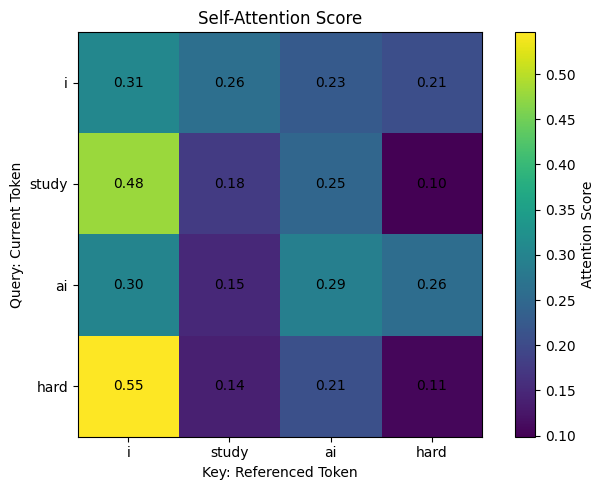

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(attention_df.values)

ax.set_xticks(range(len(sentence_tokens)))
ax.set_xticklabels(sentence_tokens)
ax.set_yticks(range(len(sentence_tokens)))
ax.set_yticklabels(sentence_tokens)
ax.set_xlabel("Key: Referenced Token")
ax.set_ylabel("Query: Current Token")
ax.set_title("Self-Attention Score")

for i in range(len(sentence_tokens)):
    for j in range(len(sentence_tokens)):
        ax.text(j, i, f"{attention_df.iloc[i, j]:.2f}",
                ha="center", va="center")

fig.colorbar(image, ax=ax, label="Attention Score")
plt.tight_layout()
plt.show()


## 13. 특정 Query Token의 Attention Score(Weight)


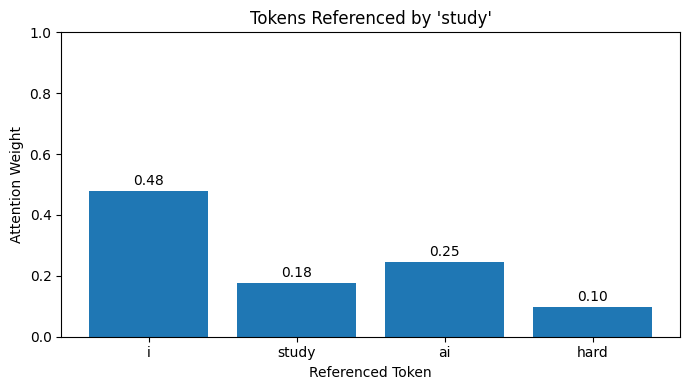

In [12]:
target_token = "study"

if target_token not in sentence_tokens:
    raise ValueError(f"{target_token!r} is not in {sentence_tokens}")

target_index = sentence_tokens.index(target_token)
target_weights = attention_weights[target_index].detach().numpy()

plt.figure(figsize=(7, 4))
plt.bar(sentence_tokens, target_weights)
plt.xlabel("Referenced Token")
plt.ylabel("Attention Weight")
plt.title(f"Tokens Referenced by '{target_token}'")
plt.ylim(0, max(1.0, float(target_weights.max()) + 0.1))

for index, value in enumerate(target_weights):
    plt.text(index, value + 0.02, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.show()
